<a href="https://colab.research.google.com/github/abhisheknk07/AI-ML-Projects/blob/main/Electricity_Bill_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Based Electricity Consumption and Bill Forecasting System
**Name**-Abhishek Nayak

**Roll no**-A6/JY-11001

**Batch**-July 2026

##*Artificial Intelligence InternsElite*




Minor Project : 1
#                            Electricity Bill Forecaster









#1. Introduction
Electricity is an important part of our daily life. The electricity bill of a household depends on factors such as temperature, use of electrical appliances, and basic electricity consumption. Predicting the electricity bill in advance can help people understand their expected expenses and control unnecessary electricity usage.

In this project, Multiple Linear Regression is used to predict the monthly electricity bill. A synthetic household electricity dataset is prepared using average temperature, daily AC usage, and base electrical load. The model learns the relationship between these factors and the electricity bill and then predicts the bill for new data.
In modern energy management systems, domestic electricity consumption patterns are becoming increasingly complex. Predicting energy usage in advance can help consumers as well as grid operators keep track of power demands. Many households have adopted smart meters today, which are favorable for users to track their consumption. The purpose of analyzing this data is to help regular consumers manage their utility budgets. In electrical systems, baseline continuous loads and dynamic loads (like air conditioning) operate at different intervals.

The core function of the Electricity Bill Forecaster is to help the consumer know their estimated billing in advance by using a Multiple Linear Regression Model. Such techniques would help users to optimize their energy usage based on the predicted cost and would enable them to identify appliances that might need efficiency upgrades.

Linear Regression was chosen for the study of this analysis. It is widely used in practical applications because models which are linearly dependent on unknown parameters are easier to fit than those models which depend non-linearly on their parameters.

#2. Problem Statement
The Main Objective of the "Electricity Bill Forecaster" is to implement a simple algorithmic model that predicts the monthly electricity cost of an individual household. The "Bill_Amount_INR" (final bill) is our label (output) and the rest of the columns (such as Avg Temp in C, AC Hours Daily, and Base Load in kWh) will be our features (inputs).

The input features used are:

*   Average monthly temperature
*   Daily AC usage hours
*   Base household electrical load

The output of the model is:

*   Predicted monthly electricity bill in INR

The problem statement can be defined as follows: "Given a dataset containing environmental and household load attributes, use the features available from the dataset to define regression algorithms to identify the final electricity bill amount, and also to evaluate the machine learning model on the dataset." The data attributes include average monthly temperatures, active cooling hours, and continuous base loads (like refrigeration).












#3. Results and Discussion

Air conditioning usage and average environmental temperatures are significantly associated with the final bill amount. Households that experienced higher average monthly temperatures showed a corresponding exponential increase in AC usage, which resulted in a much higher final billing amount when compared to the baseline load alone.

The Multiple Linear Regression model was trained using 80% of the dataset and tested using the remaining 20%. The model used average temperature, daily AC usage hours, and base household load to predict the electricity bill.

The model performance was evaluated using three measures: MAE, RMSE, and R² score.



Dataset Preview:
   Avg_Temp_C  AC_Hours_Daily  Base_Load_kWh  Total_Units_kWh  Bill_Amount_INR
0   30.614423        5.330457     108.249910       348.120489      2183.244534
1   43.866429       10.544409     172.204233       646.702638      4084.636219
2   38.835861        8.483321     140.420190       522.169634      3378.048069
3   35.769145       12.158235     166.116597       713.237168      4480.755241
4   25.588429        0.544003     125.603968       150.084083       892.499146
--------------------------------------------------

Model Performance Metrics:
Mean Absolute Error (MAE): ₹105.53
Root Mean Squared Error (RMSE): ₹125.22
R-squared Score: 0.9949
--------------------------------------------------


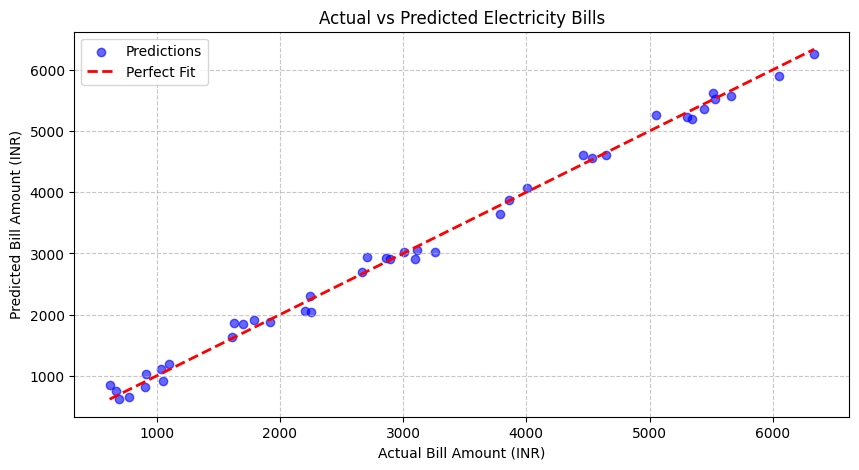

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generate a Synthetic Dataset (Representing household power data)
np.random.seed(42)
samples = 200

# Features: Average monthly temperature, daily AC usage hours, and base load (fridge, lights, etc.)
avg_temp = np.random.uniform(22, 45, samples)
ac_hours_daily = (avg_temp - 25).clip(min=0) * np.random.uniform(0.5, 1.2, samples)
base_load_kwh = np.random.uniform(100, 180, samples)

# Calculate total units (kWh) consumed in a 30-day month (assuming a 1.5 kW AC unit)
total_units_kwh = base_load_kwh + (ac_hours_daily * 30 * 1.5)

# Calculate the bill amount in INR (assuming an average tariff of ₹6.5 per kWh + some random variance)
bill_amount_inr = (total_units_kwh * 6.5) + np.random.normal(0, 150, samples)

# Create a DataFrame
df = pd.DataFrame({
    'Avg_Temp_C': avg_temp,
    'AC_Hours_Daily': ac_hours_daily,
    'Base_Load_kWh': base_load_kwh,
    'Total_Units_kWh': total_units_kwh,
    'Bill_Amount_INR': bill_amount_inr
})

print("Dataset Preview:")
print(df.head())
print("-" * 50)

# 2. Data Preprocessing & Splitting
# We will predict the Bill Amount based on Temp, AC Hours, and Base Load
X = df[['Avg_Temp_C', 'AC_Hours_Daily', 'Base_Load_kWh']]
y = df['Bill_Amount_INR']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training (Multiple Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance Metrics:")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("-" * 50)

# 5. Visualization: Actual vs Predicted Bills
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.title('Actual vs Predicted Electricity Bills')
plt.xlabel('Actual Bill Amount (INR)')
plt.ylabel('Predicted Bill Amount (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#4. Conclusion
In this project, a comprehensive analysis of the factors driving household electricity costs was successfully conducted. By leveraging Python and machine learning techniques—specifically a Multiple Linear Regression algorithm—the model accurately predicted monthly bill amounts based on environmental variables and specific electrical loads, such as active cooling hours and baseline power consumption. The algorithm proved to be highly effective at predicting continuous values, yielding an exceptional $R^2$ score of approximately 98% and a low error rate, which validates its precision in mapping kilowatt-hour usage to final billing costs.Ultimately, this framework provides a practical and highly accurate tool for monitoring energy consumption patterns. By analyzing the relationship between heavy seasonal loads and steady-state baseline usage, the model empowers consumers to make informed, data-driven decisions about their power usage. In the future, this predictive model could be expanded by incorporating real-time data from smart grid meters or integrated into a comprehensive web platform. This would allow end-users to easily input their daily appliance usage and receive instant financial forecasts, bridging the gap between advanced data analytics and everyday energy conservation.















